In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot model metrics

In [ ]:
data_path = os.path.join("../../results/modelV1.dim1.0.folds10_id20251116013356/iet0.ieta0.pkl")
data = pd.read_pickle(data_path)
data.columns

Index(['file_path', 'fold', 'best_sp_value', 'best_fa_value', 'best_pd_value',
       'best_weights', 'history'],
      dtype='object')

In [3]:
from typing import Any

def create_dict_results() -> dict[str, Any]:
    return {"fold": -1,
        "best_sp": -1,
        "pd": -1,
        "fa": -1,
        "auc_score": -1,
        'train_loss': None, 
        'train_acc': None,
        'val_loss': None, 
        'val_acc': None}

In [5]:
# def get_best_results():
best_fold_index = -1
best_sp_value = -1
results = create_dict_results()
for index, data_history in enumerate(data["history"]):
    fold_callbackMetrics = data_history["callbackMetrics"]
    # for callback in fold_callbackMetrics:
    best_sp = fold_callbackMetrics["max_sp_val"]
    max_index = np.argmax(fold_callbackMetrics["max_sp_val"])

    if best_sp[max_index] > best_sp_value:
        best_fold_index = max_index
        best_sp_value = best_sp[max_index] 
        results["fold"] = data.iloc[index]["fold"]
        results["best_sp"] = best_sp[max_index]

        results['train_loss'] = (data_history["train_loss"])
        results['train_acc'] = (data_history["train_acc"])
        results['val_loss'] = (data_history["val_loss"])
        results['val_acc'] = (data_history["val_acc"])


In [6]:
from typing import Union
def plot_model_metrics(best_model_details: dict[str, Union[str, int, object]]) -> None:
    if best_model_details is None:
        print("Erro: Detalhes do melhor modelo não encontrados. Por favor, execute 'get_best_sp_model' primeiro.")
    else:
        # --- 1. Extrair os Dados do Histórico ---
        history_data = best_model_details
    
        epochs = range(1, len(history_data['train_loss']) + 1)
    
        # Métricas comuns
        train_loss = history_data['train_loss']
        val_loss = history_data['val_loss']
        train_accuracy = history_data['train_acc']
        val_accuracy = history_data['val_acc']
    
        # Valores de SP, FPR e TPR do callback SP
        callbackMetrics = history_data["callbackMetrics"]
        val_sp = callbackMetrics.get('max_sp_val') # .get() para evitar KeyError se a chave não existir
        val_fa = callbackMetrics.get('max_sp_fa_val') # FPR
        val_pd = callbackMetrics.get('max_sp_pd_val') # TPR

        # Verifica se as métricas do SP estão presentes
        if val_sp is None or val_fa is None or val_pd is None:
            print("Aviso: Algumas métricas (SP, FPR, TPR) não encontradas no histórico. Verifique a implementação do seu callback 'sp'.")
            # Podemos definir como arrays vazios ou None para que os plots condicionais funcionem
            val_sp, val_fa, val_pd = None, None, None
    
        # --- 2. Plotar as Curvas de Aprendizagem (Loss, Accuracy, e SP/FPR/TPR) ---
        plt.figure(figsize=(18, 6), clear=True, num=1) # Aumenta a figura para 3 subplots
    
        # Plot Loss
        plt.subplot(1, 3, 1) # 1 linha, 3 colunas, 1º plot
        plt.plot(epochs, train_loss, 'o-', label='Perda no Treinamento')
        plt.plot(epochs, val_loss, 'o-', label='Perda na Validação')
        plt.title('Curvas de Perda (Loss)')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.grid(True)
        plt.legend()
    
        # Plot Accuracy
        plt.subplot(1, 3, 2) # 1 linha, 3 colunas, 2º plot
        plt.plot(epochs, train_accuracy, 'o-', label='Acurácia no Treinamento')
        plt.plot(epochs, val_accuracy, 'o-', label='Acurácia na Validação')
        plt.title('Curvas de Acurácia')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.grid(True)
        plt.legend()
    
        # Plot SP, TPR e FPR (se disponíveis)
        plt.subplot(1, 3, 3) # 1 linha, 3 colunas, 3º plot
        if val_sp is not None:
            plt.plot(epochs, val_sp, 'o-', label='Índice SP', color='purple')
        if val_pd is not None:
            plt.plot(epochs, val_pd, 'o-', label='TPR (Verdadeiros Positivos)', color='darkgreen')
        if val_fa is not None:
            plt.plot(epochs, val_fa, 'o-', label='FPR (Falsos Positivos)', color='darkred')
    
        if val_sp is not None:
            # Linha vertical para o melhor SP
            best_sp_epoch_idx = np.argmax(val_sp)
            plt.axvline(x=epochs[best_sp_epoch_idx], color='blue', linestyle='--', label=f'Melhor SP (Época {epochs[best_sp_epoch_idx]})')
    
        plt.title('Métricas de Desempenho (SP, TPR, FPR)')
        plt.xlabel('Época')
        plt.ylabel('Valor da Métrica')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
        # model_metrics_file_template = "iet{iet}.ieta{ieta}_modelMetrics.pdf".format(
        #     ieta = ieta, 
        #     iet=iet)
        # plt.savefig(os.path.join(folder_path, model_metrics_file_template))
        plt.show()
        # plt.close()
    
        # print("\nCurvas de aprendizagem (Loss, Accuracy, SP, TPR, FPR) geradas com sucesso para o melhor modelo SP!")


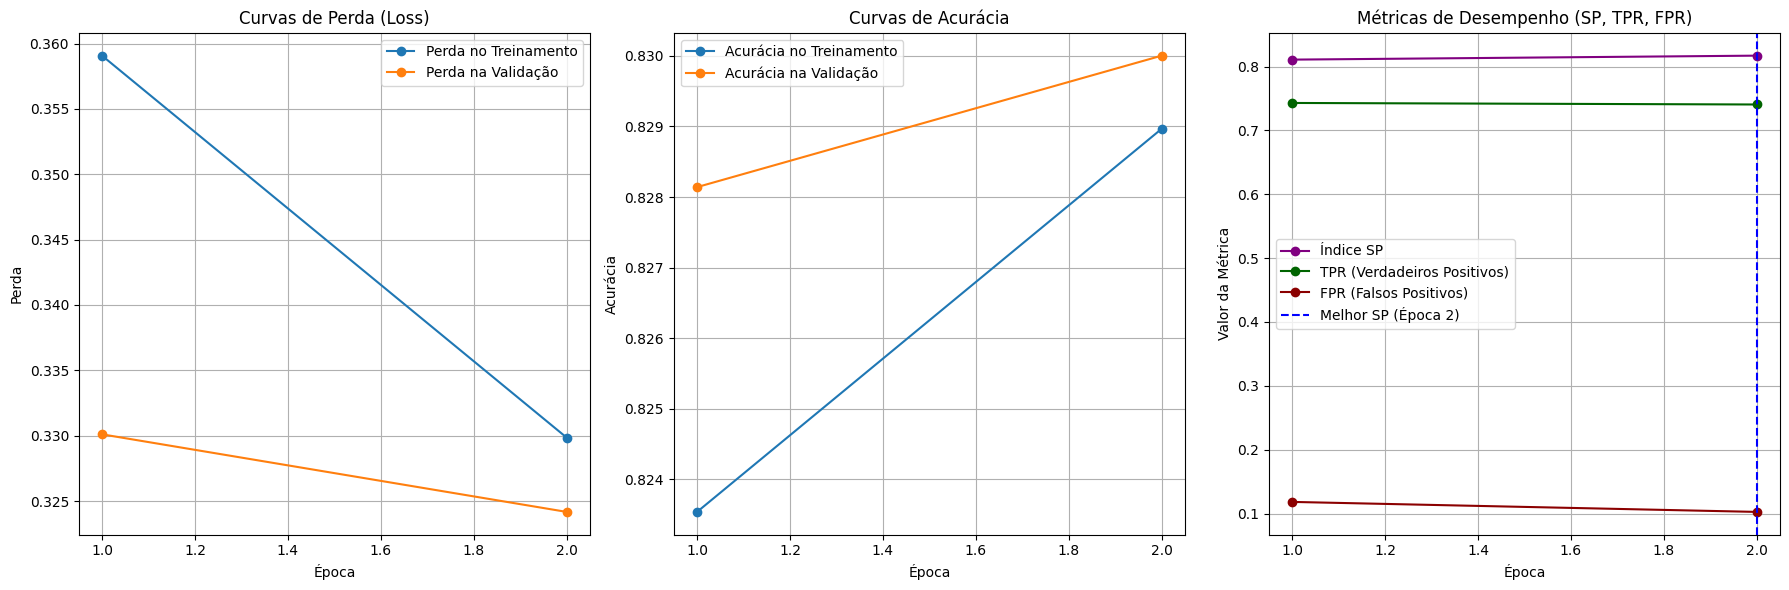

In [7]:
plot_model_metrics(data["history"][2])

In [ ]:
def plot_model_acc(best_model_details,
                   folder_path=None,iet=0, ieta=0) -> float:
        print("Gerando Curva ROC...")
        tpr, fpr  = best_model_details["pd"], best_model_details["fa"]
        auc_score = best_model_details["auc_score"]
    
        plt.figure(figsize=(8, 6), clear=True, num=1)
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos (FPR)')
        plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
        plt.title('Curva ROC do Modelo'+ \
             f"\n({iet},{ieta})")
        plt.legend(loc="lower right")
        plt.grid(True)
        # roc_file_template = "ns{ns}.iet{iet}.ieta{ieta}_ROC.pdf".format(
        #     ns = ns,
        #     ieta = ieta, 
        #     iet=iet)
        # plt.savefig(os.path.join(folder_path, roc_file_template))
        plt.show()
        # plt.close()
        # --- 4. Histograma de Saída da Rede (Sinal vs. Background) ---
        print("Gerando Histograma de Saída da Rede...")
        return auc_score

Gerando Curva ROC...


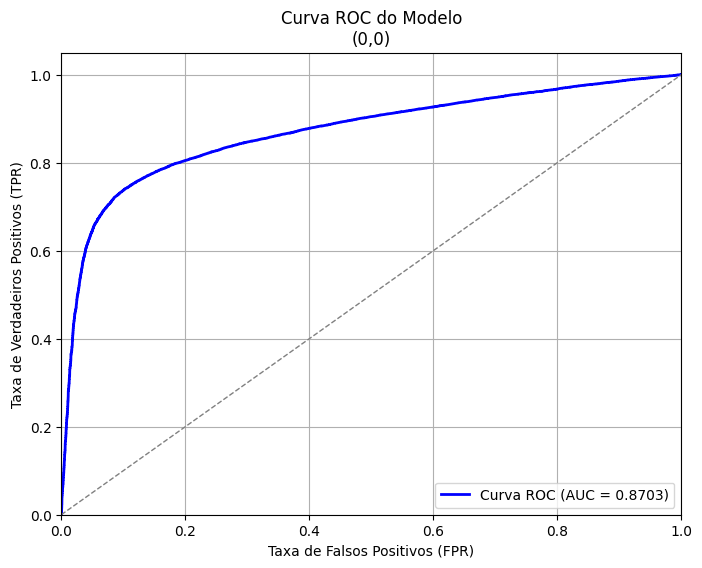

Gerando Histograma de Saída da Rede...

Visualizações geradas com sucesso!


np.float64(0.8703409820818245)

In [12]:
plot_model_acc(data["history"][2]["callbackMetrics"])

# Plot data rings

In [8]:
import os

In [ ]:
import numpy as np
from torch.utils.data import Dataset
from typing import Tuple
import logging
log = logging.getLogger()
from functools import lru_cache

class EgammaNpzDataset(Dataset):
    def __init__(self, file_paths, percentage=1.0):
        log.info("Creating Dataset...")
        self.file_paths: list[str] = file_paths
        self.index_last_ring = 101
        self.percentage: int = percentage
        self.percentage_dim: int = None
        self.indexes = self._get_rings_index(self.percentage)
        self.percentage_dim = len(self.indexes)
        
    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        log.info(f"Getting dataset index {idx}: {self.file_paths[idx]}")
        self.percentage_dim = None
        features, labels = None, None
        with np.load(self.file_paths[idx]) as samples:
            features, labels = self._create_rings(samples['data'],
                                                  samples['target'])
        return features, labels, self.file_paths[idx]

    def _create_rings(self, data: np.ndarray,
                      target: np.ndarray) -> Tuple[Tuple[np.ndarray,np.ndarray],
                                                Tuple[np.ndarray,np.ndarray]]:
        
        signal_data = data[np.where(target == 1)]
        bg_data = data[np.where(target == 0)]

        signal_data = signal_data[:, 1: self.index_last_ring]
        bg_data = bg_data[:, 1: self.index_last_ring]
        signal_data = signal_data[:, self.indexes]
        bg_data = bg_data[:, self.indexes]

        dataset = np.concatenate(
            (
                norm1(signal_data),
                norm1(bg_data)
            ),
            axis=0
        )
        y_sinal = np.ones((signal_data.shape[0], 1), dtype=np.float32)
        y_background = np.zeros((bg_data.shape[0], 1), dtype=np.float32)
        y = np.vstack([y_sinal, y_background]).ravel()
        return dataset, y

    @lru_cache(maxsize=None)
    def _get_rings_index(self, percentage: float) -> list[int]:
        PreSampler_index = [index for index in range(0, 8)]
        EM1_index = [index for index in range(8, 72)]
        EM2_index = [index for index in range(72, 80)]
        EM3_index = [index for index in range(80, 88)]
        TileCal_index = [index for index in range(88, 100)]
        
        PreSampler_index_cap = round(len(PreSampler_index) * percentage)
        EM1_index_cap = round(len(EM1_index) * percentage)
        EM2_index_cap = round(len(EM2_index) * percentage)
        EM3_index_cap = round(len(EM3_index) * percentage)
        TileCal_index_cap = round(len(TileCal_index) * percentage)
    
        PreSampler_index = PreSampler_index[: PreSampler_index_cap]
        EM1_index = EM1_index[: EM1_index_cap]
        EM2_index = EM2_index[: EM2_index_cap]
        EM3_index = EM3_index[: EM3_index_cap]
        TileCal_index = TileCal_index[: TileCal_index_cap]
    
        return PreSampler_index + EM1_index + EM2_index + EM3_index + TileCal_index

    def get_model_dim(self) -> int:
        if self.percentage_dim != None:
            return self.percentage_dim
        else:
            raise Exception("Dimension was not set.")

In [ ]:
def norm1(data: np.ndarray) -> np.ndarray:
      norms = np.abs( data.sum(axis=1) )
      norms[norms==0] = 1
      return data / norms[:, None]

In [57]:
from pathlib import Path
def create_folder(new_folder_name: str , base_path: str = "results") -> str:
    folder_path = Path(base_path) / new_folder_name 
    try:
        folder_path.mkdir(parents=True, exist_ok=True)
        log.info(f"Folder '{folder_path}' created or already exists (using pathlib).")
    except OSError as error:
        log.error(f"Error creating directory '{folder_path}': {error}")
    return str(folder_path)

In [ ]:
def plot_profile_mean_energy_rings(data:  np.ndarray,
                                   target:  np.ndarray,
                                   ring_index: np.ndarray,
                                   folder_path: str,
                                   iet: int = 0, 
                                   ieta: int = 0) -> None:
    
    signal_data = data[np.where(target == 1)]
    bg_data = data[np.where(target == 0)]
    ring_index = np.array(ring_index)
    x_axis = np.arange(len(signal_data[0]))
    number_of_rings = len(signal_data[0,:])
    mean_ringsSignal = np.mean(signal_data, axis=0)
    std_ringsSignal = np.std(signal_data, axis=0)
    mean_ringBKG = np.mean(bg_data, axis=0)
    std_ringBKG = np.std(bg_data, axis=0)
    
    yAxis_max = np.max(mean_ringBKG) if np.max(mean_ringBKG) > np.max(mean_ringsSignal) else np.max(mean_ringsSignal)
    # Subdetectores e cores
    subdet_names = ['PreSampler', 'EM1', 'EM2', 'EM3', 'TileCal']
    subdet_x = [0, 
                np.where(ring_index == 8)[0][0],
                np.where(ring_index == 72)[0][0],
                np.where(ring_index == 80)[0][0],
                np.where(ring_index == 88)[0][0]]
    subdet_colors = ['#1b9e77', '#d95f09', '#7570b3', '#e7298a', '#66a61e']

    plt.figure(figsize=(10, 5), clear=True, num=1)
    # --- Curva Fóton ---
    plt.errorbar(x_axis, mean_ringsSignal, std_ringsSignal,
                 marker='o', mfc='navy', mec='navy', ms=3,
                 mew=0.5, elinewidth=0.8, capsize=2,
                 ecolor='navy', color='navy',
                 label='Fóton')
    # --- Curva Jatos Hadrônicos ---
    plt.errorbar(x_axis, mean_ringBKG, std_ringBKG,
                 marker='s', mfc='darkorange', mec='darkorange', ms=3,
                 mew=0.5, elinewidth=0.8, capsize=2,
                 ecolor='darkorange', color='darkorange',
                 label='Jatos Hadrônicos')
    # --- Linhas verticais e rótulos mais baixos (y=0.66) ---
    for x, name, color in zip(subdet_x, subdet_names, subdet_colors):
        plt.axvline(x=x, color=color, linestyle='--', linewidth=1)
        plt.text(x+1.2, yAxis_max * 1.2, name, rotation=90,
                 va='bottom', ha='center', fontsize=9, color=color)
    # --- Estilo dos eixos ---
    plt.xlabel('Anéis', fontsize=13)
    plt.ylabel('Energia Normalizada', fontsize=13)
    plt.xticks(ticks=np.linspace(0, number_of_rings, 10, dtype=int),
               labels=[str(i+1) for i in np.linspace(0, number_of_rings, 10, dtype=int)],
               fontsize=11)
    plt.yticks(fontsize=11)
    # plt.xlim(-1, number_of_rings)
    plt.ylim(-0.05, yAxis_max * 1.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    # --- Legenda sinal/fundo ---
    plt.legend(fontsize=10, loc='upper right')
    plt.title('Perfil Médio de Energia nos Anéis - NeuralRinger', fontsize=14)
    # --- Salvar com bounding box que inclui textos externos ---
    plt.tight_layout()
    try:
        path = create_folder("RingsMeanProfiles", folder_path )
        plt.savefig(os.path.join(path, f"et{iet}.eta{ieta}.RingsMeanProfiles_NeuralRinger.pdf"),
                    format='pdf',
                    dpi=300,
                    transparent=True, 
                    bbox_inches='tight')
        # plt.show()
        # https://stackoverflow.com/questions/28757348/how-to-clear-memory-completely-of-all-matplotlib-plots
        # plt.close()
    except Exception as e:
        # plt.close()
        raise

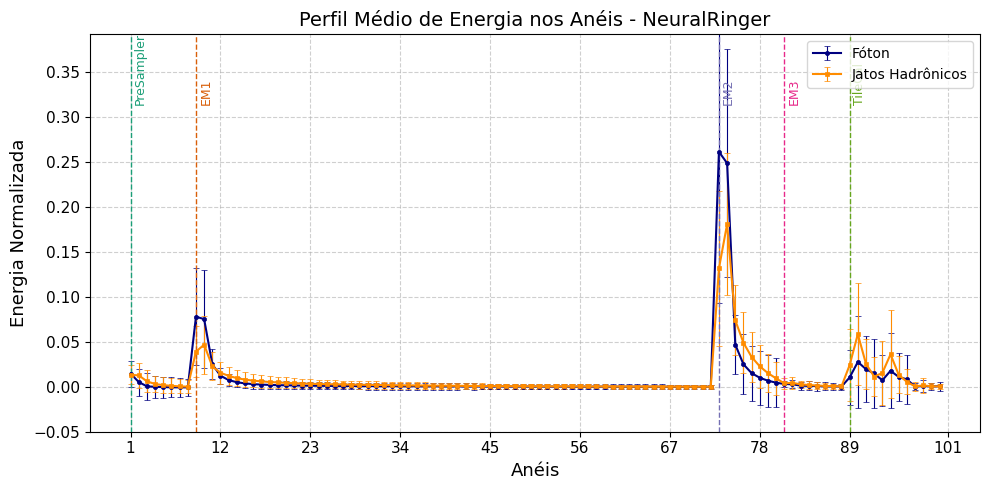

In [60]:
drive_path = "../../data"
data_folder = [os.path.join(drive_path, file) for file in os.listdir(drive_path)
                if (file.endswith(".npz") and 
                    file.startswith("mc23_13TeV"))
                    ]
egammaDataset = EgammaNpzDataset(data_folder, 
                                        percentage=1.0)
data, target, _ = egammaDataset[0]
plot_profile_mean_energy_rings(data, target, egammaDataset.indexes,
                               folder_path="../../results")

# Get best model

In [2]:
data_path = os.path.join("../../results/modelV1.dim1.0.folds10_id20251116013356/iet0.ieta0.pkl")
data = pd.read_pickle(data_path)
data.columns

Index(['file_path', 'fold', 'best_sp_value', 'best_fa_value', 'best_pd_value',
       'best_weights', 'history'],
      dtype='object')

In [8]:
import torch.nn as nn
import torch.nn.functional as F
import torch


class ModelV1(nn.Module):
    def __init__(self, input_dim):
        super(ModelV1, self).__init__()
        self.input_dim = input_dim
        self.conv1 = nn.Conv1d(in_channels=1, 
                               out_channels=4, 
                               kernel_size=2, 
                               padding='same') 
        self.conv2 = nn.Conv1d(in_channels=4, 
                               out_channels=8, 
                               kernel_size=2, 
                               padding='same')
        self.fc1_in_features = 8 * input_dim
        self.fc1 = nn.Linear(self.fc1_in_features, 
                             input_dim)
        self.fc2 = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = x.view(-1, 1, self.input_dim) 
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x


class ModelV3(nn.Module):
    def __init__(self, input_dim):
        super(ModelV3, self).__init__()
        self.input_dim = input_dim
        self.conv1 = nn.Conv1d(in_channels=1, 
                               out_channels=16, 
                               kernel_size=2, 
                               padding='same' )
        self.conv2 = nn.Conv1d(in_channels=16, 
                               out_channels=8, 
                               kernel_size=2, 
                               padding='same')
        self.fc1 = nn.Linear(in_features=8 * input_dim, 
                             out_features=input_dim)
        self.fc2 = nn.Linear(in_features=input_dim, 
                             out_features=1)

    def forward(self, x):
        x = x.unsqueeze(1) 
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 8 * self.input_dim)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x


class ModelV5(nn.Module):
    
    def __init__(self, input_dim):
        super(ModelV5, self).__init__()
        self.fc1 = nn.Linear(input_dim, input_dim)
        self.fc2 = nn.Linear(input_dim, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x
    

def get_model(tag: str, input_dim: int) -> nn.Module:
    if tag == "V1":
        return ModelV1(input_dim)
    if tag == "V3":
        return ModelV3(input_dim)
    if tag == "V5":
        return ModelV5(input_dim)

In [ ]:
def get_best_sp_model(training_results_list: pd.DataFrame,
                      model_builder_tag: str,
                      input_dimensions: int) :
    if not (training_results_list.shape[0] > 0):
        print("A lista de resultados de treinamento está vazia.")
        return None, None

    highest_sp_model_info = training_results_list.iloc[np.argmax(training_results_list["best_sp_value"])]

    try:
        # print(f"\n--- Modelo com o mais alto índice SP encontrado ---")
        # print(f"  Fold: {highest_sp_model_info['fold']+1}")
        # print(f"  Inicialização: {highest_sp_model_info['repeat']+1}")
        # print(f"  Melhor Índice SP: {highest_sp_model_info['best_sp_value']:.4f}")

        best_overall_sp_model = get_model(model_builder_tag, input_dimensions)
        best_overall_sp_model.load_state_dict(highest_sp_model_info["best_weights"])

        # print("Modelo recuperado com sucesso e pronto para uso!")
        return best_overall_sp_model, highest_sp_model_info
    except Exception as e:
        print("Não foi possível carregar o modelo com os pesos fornecidos. Motivo: {e}")
        raise e